# BuildTrack 3D — Complete Senior Colab Notebook

Depth-aware construction progress monitoring using:

- Roboflow public construction-progress dataset
- YOLO segmentation
- Visual progress estimation
- Depth Anything V2 monocular depth
- Mask-depth fusion
- Zone-level progress
- Planned vs actual progress
- Dataset health check
- Per-class metrics
- Error analysis
- Temporal smoothing
- Optional ablation study

No deployment and no UI are included.

# 1. Install libraries

In Colab, use GPU:

`Runtime → Change runtime type → T4 GPU`

In [1]:
!pip -q install ultralytics roboflow opencv-python matplotlib pandas pyyaml tqdm pillow transformers accelerate

# 2. Imports and global settings

In [2]:
from pathlib import Path
import os
import time
import json
import random
import yaml
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

import torch
from ultralytics import YOLO

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
OUTPUT_DIR = ROOT / "outputs"
MODEL_DIR = ROOT / "models"

for p in [DATA_DIR, OUTPUT_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

YOLO_MODEL_SIZE = "yolov8n-seg.pt"
IMG_SIZE = 640
EPOCHS = 40
BATCH = 8
CONF_THRESHOLD = 0.25

PROGRESS_WEIGHTS = {
    "rebar": 0.25,
    "formwork": 0.25,
    "concrete": 0.35,
    "tiles": 0.15
}

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("Project root:", ROOT)

Torch: 2.11.0
CUDA available: False
Project root: /Users/nehanaiksatam/Downloads


# 3. Download the public construction-progress dataset

Paste your Roboflow API key below.

Roboflow is used only for dataset download. It is not used for deployment.

## Local Mac note

When running locally, `ROOT = Path.cwd()` is your current notebook folder. The dataset will be downloaded under:

```text
./data/construction_progress_lexandre
```

If you already downloaded the dataset manually, unzip it anywhere under the notebook folder, `./data`, `~/Downloads`, or `~/Desktop`; the notebook will search those locations for `data.yaml`.


In [6]:
# Paste your Roboflow API key here.
# On Mac/local Jupyter, environment variables are often not loaded automatically,
# so pasting the key directly here is the simplest option.

ROBOFLOW_API_KEY = os.getenv("ROBOFLOW_API_KEY", "ULHJgmRlGv9TyU1BQV80")

# Example:
# ROBOFLOW_API_KEY = "rf_xxxxxxxxxxxxxxxxxxxxx"

DATASET_CANDIDATES = [
    {
        "workspace": "lexandre",
        "project": "construction-progress-monitoring-d1qhs",
        "version": 1,
        "location": DATA_DIR / "construction_progress_lexandre"
    },
    {
        "workspace": "abradabra",
        "project": "construction-progress-monitoring-q7lof",
        "version": 1,
        "location": DATA_DIR / "construction_progress_abradabra"
    }
]

RF_FORMAT = "yolov8"

DATASET_LOCATION = None
DATA_YAML = None

print("Current notebook folder:", ROOT)
print("Dataset will be searched/downloaded under:", DATA_DIR)


Current notebook folder: /Users/nehanaiksatam/Downloads
Dataset will be searched/downloaded under: /Users/nehanaiksatam/Downloads/data


# 4. Dataset download and path-fix helper functions

In [7]:
def local_search_roots():
    """Search only reasonable local folders so Mac does not scan the whole disk."""
    roots = [
        DATA_DIR,
        ROOT,
        ROOT / "data",
        Path.home() / "Downloads",
        Path.home() / "Desktop",
    ]

    # Colab compatibility; ignored on Mac if it does not exist.
    roots.append(Path("/content"))

    # Remove duplicates while preserving order.
    unique = []
    for r in roots:
        r = Path(r)
        if r not in unique:
            unique.append(r)
    return unique


def find_data_yaml(search_roots=None):
    if search_roots is None:
        search_roots = local_search_roots()

    candidates = []

    for root in search_roots:
        root = Path(root)
        if not root.exists():
            continue

        for yml in root.rglob("data.yaml"):
            try:
                with open(yml, "r") as f:
                    cfg = yaml.safe_load(f)

                if isinstance(cfg, dict) and "train" in cfg and "names" in cfg:
                    candidates.append(yml)
            except Exception:
                pass

    if not candidates:
        return None

    candidates = sorted(
        candidates,
        key=lambda x: (
            "construction" not in str(x).lower(),
            "progress" not in str(x).lower(),
            len(str(x))
        )
    )

    return candidates[0]


def count_images(folder):
    folder = Path(folder)
    if not folder.exists():
        return 0
    return sum(1 for p in folder.iterdir() if p.suffix.lower() in IMG_EXTS)


def download_dataset_from_roboflow():
    from roboflow import Roboflow

    if not ROBOFLOW_API_KEY or "PASTE_YOUR" in ROBOFLOW_API_KEY:
        raise ValueError(
            "Roboflow API key is missing. Paste it into ROBOFLOW_API_KEY, "
            "or manually download/unzip the dataset and rerun this cell."
        )

    rf = Roboflow(api_key=ROBOFLOW_API_KEY)
    errors = []

    for cfg in DATASET_CANDIDATES:
        try:
            print(f"Trying: {cfg['workspace']}/{cfg['project']} version {cfg['version']}")

            project = rf.workspace(cfg["workspace"]).project(cfg["project"])
            dataset = project.version(cfg["version"]).download(
                RF_FORMAT,
                location=str(cfg["location"])
            )

            dataset_location = Path(dataset.location)
            data_yaml = find_data_yaml([dataset_location, dataset_location.parent, DATA_DIR, ROOT])

            if data_yaml is None:
                raise FileNotFoundError(f"No data.yaml found under {dataset_location}")

            print("Dataset downloaded.")
            print("Dataset location:", dataset_location)
            print("data.yaml:", data_yaml)

            return dataset_location, data_yaml

        except Exception as e:
            msg = f"{cfg['workspace']}/{cfg['project']} v{cfg['version']} failed: {e}"
            print(msg)
            errors.append(msg)

    raise RuntimeError("All dataset candidates failed:\n" + "\n".join(errors))


# First, try to find an already-downloaded dataset. If not found, try Roboflow download.
found_existing = find_data_yaml()

if found_existing is not None:
    DATA_YAML = found_existing
    DATASET_LOCATION = DATA_YAML.parent
    print("Found existing dataset:", DATA_YAML)
else:
    try:
        DATASET_LOCATION, DATA_YAML = download_dataset_from_roboflow()
    except Exception as e:
        print("Dataset download/find did not complete.")
        print("Reason:", e)
        print("\nManual fallback:")
        print("1. Open Roboflow dataset page.")
        print("2. Download dataset in YOLOv8 format.")
        print("3. Unzip it under ./data or ~/Downloads.")
        print("4. Rerun this cell.")

print("\nFinal DATASET_LOCATION:", DATASET_LOCATION)
print("Final DATA_YAML:", DATA_YAML)


Trying: lexandre/construction-progress-monitoring-d1qhs version 1
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /Users/nehanaiksatam/Downloads/data/constructi


Dataset downloaded.
Dataset location: /Users/nehanaiksatam/Downloads/data/construction_progress_lexandre
data.yaml: /Users/nehanaiksatam/Downloads/data/construction_progress_lexandre/data.yaml

Final DATASET_LOCATION: /Users/nehanaiksatam/Downloads/data/construction_progress_lexandre
Final DATA_YAML: /Users/nehanaiksatam/Downloads/data/construction_progress_lexandre/data.yaml


# 5. Auto-fix Roboflow/Colab dataset paths

This handles the issue where `data.yaml` contains paths like `../train/images`.

In [8]:
def find_split_image_dir(split_names, search_root):
    search_root = Path(search_root)
    candidates = []

    for split in split_names:
        candidates.extend([
            search_root / split / "images",
            search_root.parent / split / "images",
            search_root / "dataset" / split / "images",
            DATA_DIR / split / "images",
            ROOT / split / "images",
        ])

    for root in [search_root, search_root.parent, DATA_DIR, ROOT, Path.home() / "Downloads", Path.home() / "Desktop"]:
        if root.exists():
            for img_dir in root.rglob("images"):
                parts = [x.lower() for x in img_dir.parts]
                if any(split in parts for split in split_names):
                    candidates.append(img_dir)

    candidates = list(dict.fromkeys(candidates))
    valid = []

    for c in candidates:
        n = count_images(c)
        if n > 0:
            valid.append((c, n))

    if not valid:
        return None, 0

    valid = sorted(valid, key=lambda x: x[1], reverse=True)
    return valid[0]


def labels_dir_from_images_dir(image_dir):
    image_dir = Path(image_dir)
    return image_dir.parent / "labels"


def patch_data_yaml():
    global DATASET_LOCATION, DATA_YAML, CLASS_NAMES
    global train_img_dir, val_img_dir, test_img_dir

    if DATA_YAML is None or not Path(DATA_YAML).exists():
        print("DATA_YAML is missing. Searching local folders...")
        found = find_data_yaml()

        if found is None:
            raise FileNotFoundError(
                "Could not find data.yaml. The dataset is not downloaded/unzipped yet.\n"
                "Fix: paste ROBOFLOW_API_KEY and rerun the dataset download cell, or manually unzip the YOLOv8 dataset under ./data, ~/Downloads, or ~/Desktop."
            )

        DATA_YAML = found
        DATASET_LOCATION = DATA_YAML.parent

    DATA_YAML = Path(DATA_YAML)
    DATASET_LOCATION = Path(DATASET_LOCATION)

    train_img_dir, train_count = find_split_image_dir(["train"], DATASET_LOCATION)
    val_img_dir, val_count = find_split_image_dir(["valid", "val"], DATASET_LOCATION)
    test_img_dir, test_count = find_split_image_dir(["test"], DATASET_LOCATION)

    print("Detected image folders:")
    print("Train:", train_img_dir, "count:", train_count)
    print("Val:", val_img_dir, "count:", val_count)
    print("Test:", test_img_dir, "count:", test_count)

    if train_img_dir is None or train_count == 0:
        raise FileNotFoundError("Could not find train/images with images. Check that the dataset was exported in YOLOv8 format and unzipped fully.")
    if val_img_dir is None or val_count == 0:
        raise FileNotFoundError("Could not find valid/images or val/images with images. Check dataset export/unzip.")

    with open(DATA_YAML, "r") as f:
        data_cfg = yaml.safe_load(f)

    CLASS_NAMES = data_cfg.get("names", ["concrete", "formwork", "rebar", "tiles"])

    if isinstance(CLASS_NAMES, dict):
        CLASS_NAMES = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())]

    data_cfg["names"] = CLASS_NAMES
    data_cfg["nc"] = len(CLASS_NAMES)
    data_cfg["train"] = str(Path(train_img_dir).resolve())
    data_cfg["val"] = str(Path(val_img_dir).resolve())

    if test_img_dir is not None:
        data_cfg["test"] = str(Path(test_img_dir).resolve())

    fixed_yaml = DATA_YAML.parent / "data_local_fixed.yaml"

    with open(fixed_yaml, "w") as f:
        yaml.safe_dump(data_cfg, f, sort_keys=False)

    DATA_YAML = fixed_yaml

    print("\nPatched YAML saved:", DATA_YAML)
    print("Classes:", CLASS_NAMES)

    print("\nLabel folders:")
    print("Train labels:", labels_dir_from_images_dir(train_img_dir))
    print("Val labels:", labels_dir_from_images_dir(val_img_dir))
    print("Test labels:", labels_dir_from_images_dir(test_img_dir) if test_img_dir else None)

    print("\nPatched data.yaml:")
    with open(DATA_YAML, "r") as f:
        print(f.read())

    return DATA_YAML


DATA_YAML = patch_data_yaml()


Detected image folders:
Train: /Users/nehanaiksatam/Downloads/data/construction_progress_lexandre/train/images count: 908
Val: /Users/nehanaiksatam/Downloads/data/construction_progress_lexandre/valid/images count: 232
Test: /Users/nehanaiksatam/Downloads/data/construction_progress_lexandre/test/images count: 63

Patched YAML saved: /Users/nehanaiksatam/Downloads/data/construction_progress_lexandre/data_local_fixed.yaml
Classes: ['concrete', 'formwork', 'rebar', 'tiles']

Label folders:
Train labels: /Users/nehanaiksatam/Downloads/data/construction_progress_lexandre/train/labels
Val labels: /Users/nehanaiksatam/Downloads/data/construction_progress_lexandre/valid/labels
Test labels: /Users/nehanaiksatam/Downloads/data/construction_progress_lexandre/test/labels

Patched data.yaml:
names:
- concrete
- formwork
- rebar
- tiles
nc: 4
roboflow:
  license: CC BY 4.0
  project: construction-progress-monitoring-d1qhs
  url: https://universe.roboflow.com/lexandre/construction-progress-monitoring-

# 6. Dataset health check

This checks:
- image count
- label count
- missing labels
- class distribution

,split,image_dir,num_images,missing_label_files,empty_label_files
0,train,/Users/nehanaiksatam/Downloads/data/constructi...,908,0,16
1,valid,/Users/nehanaiksatam/Downloads/data/constructi...,232,0,2
2,test,/Users/nehanaiksatam/Downloads/data/constructi...,63,0,0


,split,class,instances
0,train,concrete,2409
1,train,formwork,1195
2,train,rebar,1437
3,train,tiles,1326
4,valid,concrete,711
5,valid,formwork,304
6,valid,rebar,453
7,valid,tiles,334
8,test,concrete,129
9,test,formwork,56


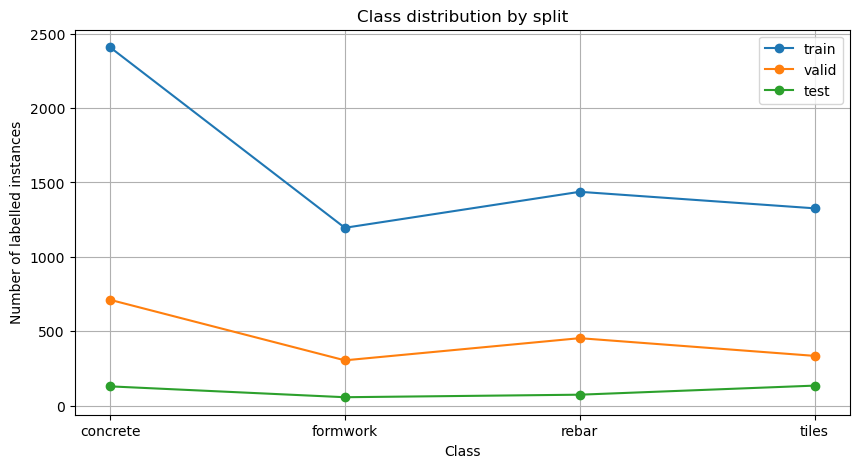

In [9]:
def image_paths_in(folder):
    folder = Path(folder)
    paths = []
    for ext in IMG_EXTS:
        paths.extend(folder.glob(f"*{ext}"))
    return sorted(paths)


def label_path_for_image(img_path):
    img_path = Path(img_path)
    return img_path.parent.parent / "labels" / f"{img_path.stem}.txt"


def parse_yolo_label_file(label_path):
    label_path = Path(label_path)
    if not label_path.exists():
        return []

    labels = []
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 3:
                labels.append(int(float(parts[0])))

    return labels


def dataset_health_report(split_name, img_dir, class_names):
    img_dir = Path(img_dir)
    images = image_paths_in(img_dir)

    missing_labels = 0
    empty_labels = 0
    class_counts = Counter()

    for img_path in images:
        label_path = label_path_for_image(img_path)

        if not label_path.exists():
            missing_labels += 1
            continue

        labels = parse_yolo_label_file(label_path)

        if len(labels) == 0:
            empty_labels += 1

        for cls_id in labels:
            if 0 <= cls_id < len(class_names):
                class_counts[class_names[cls_id]] += 1

    rows = []
    for cls in class_names:
        rows.append({
            "split": split_name,
            "class": cls,
            "instances": class_counts.get(cls, 0)
        })

    summary = {
        "split": split_name,
        "image_dir": str(img_dir),
        "num_images": len(images),
        "missing_label_files": missing_labels,
        "empty_label_files": empty_labels
    }

    return summary, pd.DataFrame(rows)


health_summaries = []
class_tables = []

for split_name, folder in [
    ("train", train_img_dir),
    ("valid", val_img_dir),
    ("test", test_img_dir if test_img_dir is not None else val_img_dir),
]:
    summary, table = dataset_health_report(split_name, folder, CLASS_NAMES)
    health_summaries.append(summary)
    class_tables.append(table)

health_df = pd.DataFrame(health_summaries)
class_distribution_df = pd.concat(class_tables, ignore_index=True)

display(health_df)
display(class_distribution_df)

health_df.to_csv(OUTPUT_DIR / "dataset_health_summary.csv", index=False)
class_distribution_df.to_csv(OUTPUT_DIR / "class_distribution.csv", index=False)

plt.figure(figsize=(10, 5))
for split in class_distribution_df["split"].unique():
    tmp = class_distribution_df[class_distribution_df["split"] == split]
    plt.plot(tmp["class"], tmp["instances"], marker="o", label=split)

plt.title("Class distribution by split")
plt.xlabel("Class")
plt.ylabel("Number of labelled instances")
plt.grid(True)
plt.legend()
plt.show()

# 7. Visualize dataset labels

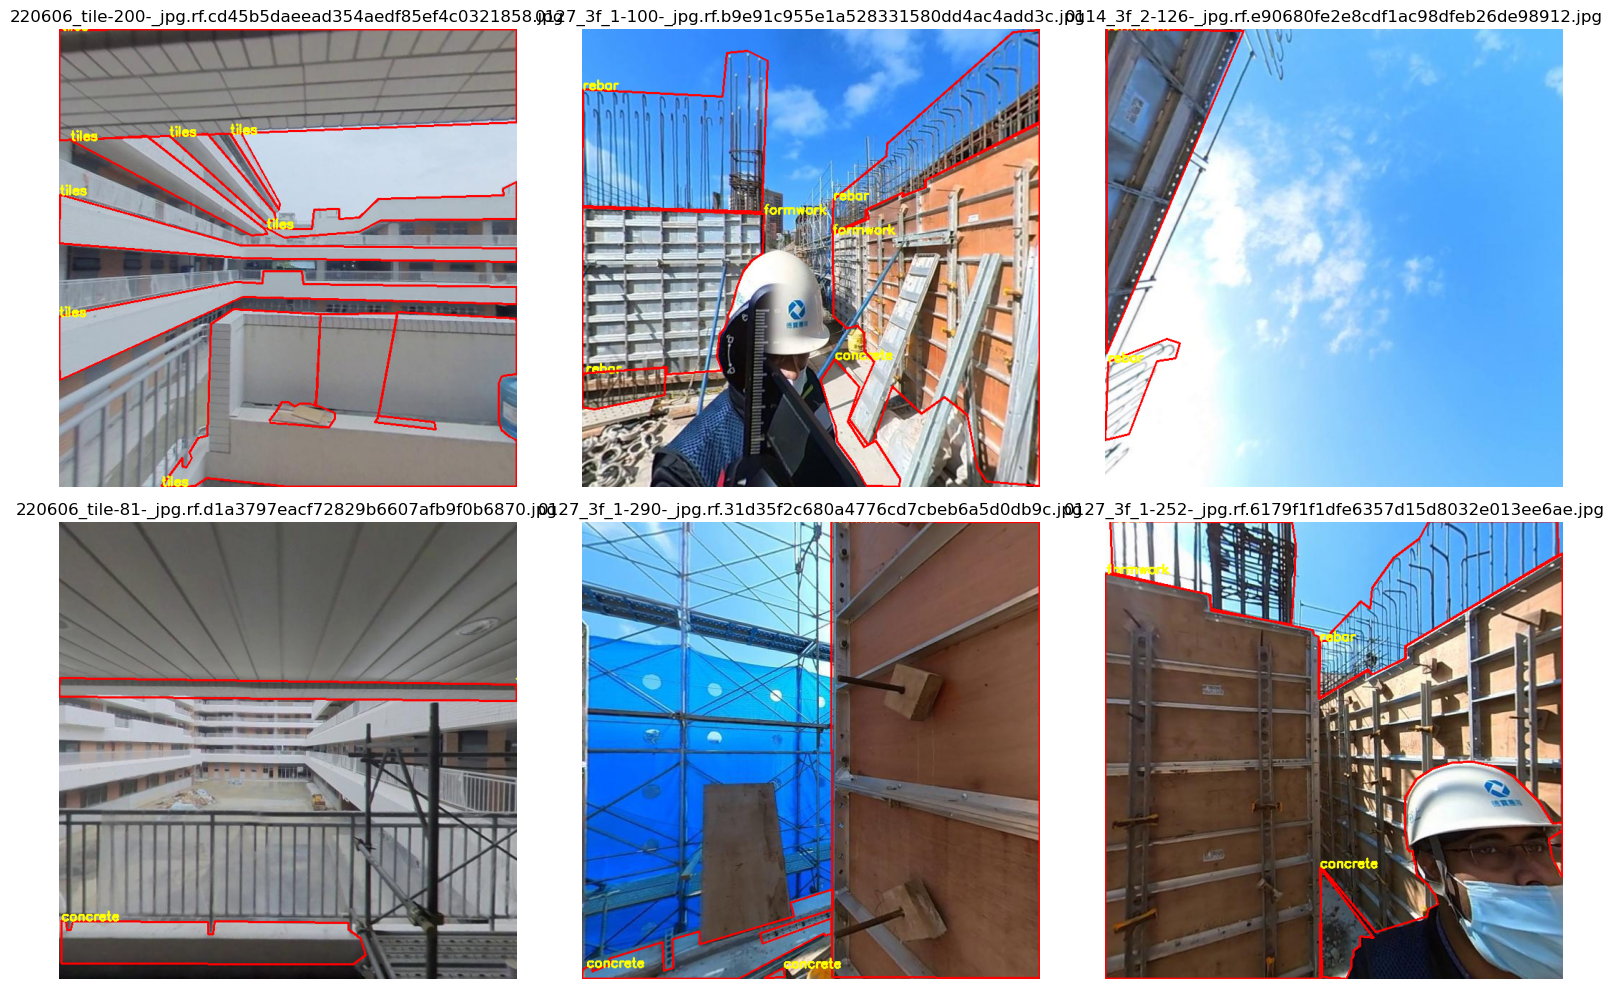

In [10]:
def draw_yolo_seg_labels(img_path, class_names):
    img_path = Path(img_path)

    image = cv2.imread(str(img_path))
    if image is None:
        raise ValueError(f"Could not read image: {img_path}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]
    overlay = image.copy()

    label_path = label_path_for_image(img_path)

    if not label_path.exists():
        return image

    with open(label_path, "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    for line in lines:
        values = list(map(float, line.split()))
        cls_id = int(values[0])

        points = values[1:]
        if len(points) < 6:
            continue

        pts = np.array(points, dtype=np.float32).reshape(-1, 2)
        pts[:, 0] *= w
        pts[:, 1] *= h
        pts = pts.astype(np.int32)

        cv2.polylines(overlay, [pts], isClosed=True, color=(255, 0, 0), thickness=2)

        label = class_names[cls_id] if cls_id < len(class_names) else str(cls_id)
        x, y = pts[0]

        cv2.putText(
            overlay, label, (int(x), int(y)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2
        )

    return overlay


sample_images = image_paths_in(train_img_dir)
sample_images = random.sample(sample_images, min(6, len(sample_images)))

plt.figure(figsize=(16, 10))
for i, img_path in enumerate(sample_images):
    vis = draw_yolo_seg_labels(img_path, CLASS_NAMES)
    plt.subplot(2, 3, i + 1)
    plt.imshow(vis)
    plt.title(img_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

# 8. Train YOLO segmentation

Segmentation is used because progress is area-based.

In [11]:
model = YOLO(YOLO_MODEL_SIZE)

train_results = model.train(
    data=str(DATA_YAML),
    task="segment",
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    patience=10,
    workers=200,
    seed=SEED,
    project=str(MODEL_DIR),
    name="buildtrack3d_yolo_seg",
    exist_ok=True,
    verbose=True
)

RUN_DIR = MODEL_DIR / "buildtrack3d_yolo_seg"
BEST_MODEL_PATH = RUN_DIR / "weights" / "best.pt"

print("Training complete.")
print("Best model path:", BEST_MODEL_PATH)

Ultralytics 8.4.48 🚀 Python-3.13.9 torch-2.11.0 CPU (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/nehanaiksatam/Downloads/data/construction_progress_lexandre/data_local_fixed.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=buildtrack3d_yolo_seg, nbs=64, nms=False, opset=None, optimize

# 9. Plot training curves

,epoch,time,train/box_loss,train/seg_loss,train/cls_loss,train/dfl_loss,train/sem_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),...,metrics/mAP50(M),metrics/mAP50-95(M),val/box_loss,val/seg_loss,val/cls_loss,val/dfl_loss,val/sem_loss,lr/pg0,lr/pg1,lr/pg2
35,36,41764.1,0.96880,1.58721,0.99567,1.14725,0,0.69099,0.63422,0.67537,...,0.66657,0.40441,1.11689,1.81225,1.21734,1.18949,0,0.000167,0.000167,0.000167
36,37,42095.3,0.96203,1.57573,0.97837,1.14043,0,0.67314,0.65173,0.67327,...,0.65764,0.39854,1.11439,1.79841,1.21892,1.18362,0,0.000136,0.000136,0.000136
37,38,42439.6,0.94680,1.55282,0.95755,1.12579,0,0.71924,0.62568,0.67471,...,0.66001,0.39717,1.11263,1.80479,1.21974,1.19092,0,0.000105,0.000105,0.000105
38,39,42771.9,0.94378,1.53940,0.93678,1.12374,0,0.68810,0.63330,0.67326,...,0.65551,0.39832,1.10338,1.79378,1.21421,1.17796,0,0.000074,0.000074,0.000074
39,40,43116.3,0.93857,1.53066,0.94891,1.12554,0,0.69388,0.63673,0.67841,...,0.66318,0.40317,1.10905,1.78725,1.20340,1.18528,0,0.000043,0.000043,0.000043


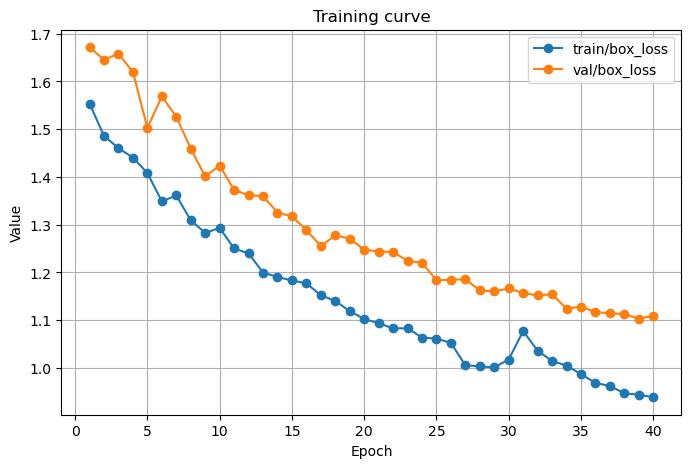

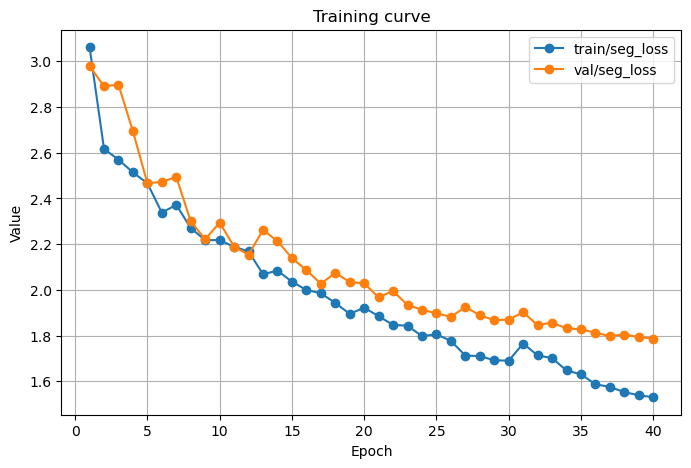

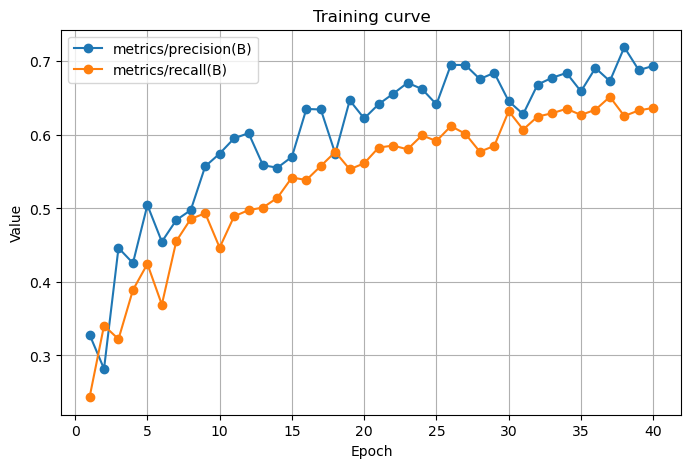

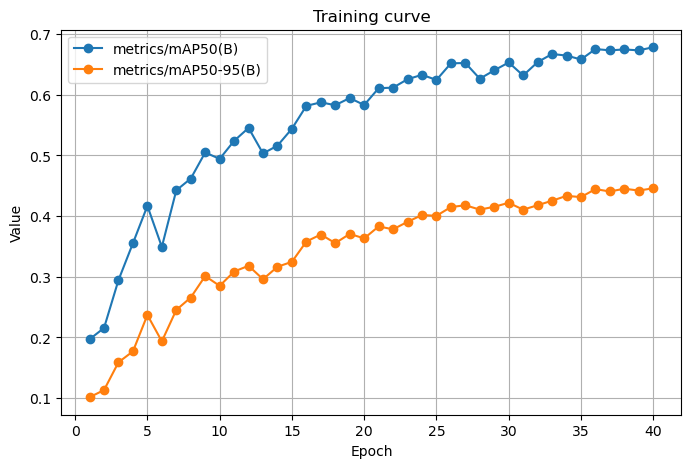

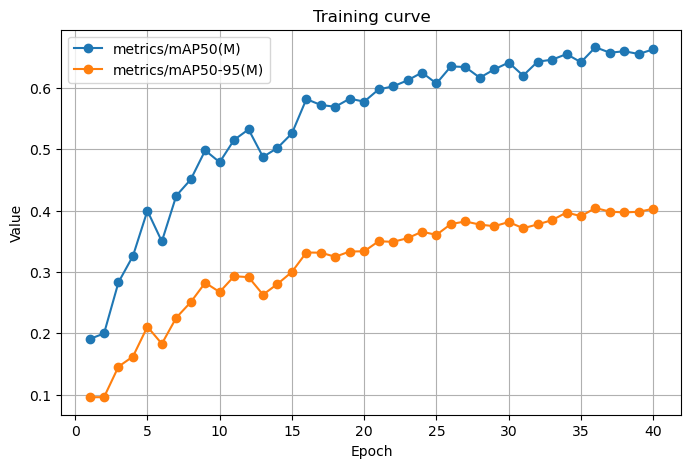

In [12]:
results_csv = RUN_DIR / "results.csv"

if results_csv.exists():
    hist = pd.read_csv(results_csv)
    hist.columns = [c.strip() for c in hist.columns]
    display(hist.tail())

    plot_groups = [
        ["train/box_loss", "val/box_loss"],
        ["train/seg_loss", "val/seg_loss"],
        ["metrics/precision(B)", "metrics/recall(B)"],
        ["metrics/mAP50(B)", "metrics/mAP50-95(B)"],
        ["metrics/mAP50(M)", "metrics/mAP50-95(M)"],
    ]

    for group in plot_groups:
        cols = [c for c in group if c in hist.columns]

        if cols:
            plt.figure(figsize=(8, 5))
            for c in cols:
                plt.plot(hist["epoch"], hist[c], marker="o", label=c)

            plt.title("Training curve")
            plt.xlabel("Epoch")
            plt.ylabel("Value")
            plt.grid(True)
            plt.legend()
            plt.show()
else:
    print("No results.csv found.")

# 10. Overall and per-class validation metrics

In [13]:
best_model = YOLO(str(BEST_MODEL_PATH))

metrics = best_model.val(
    data=str(DATA_YAML),
    imgsz=IMG_SIZE,
    conf=CONF_THRESHOLD,
    split="val",
    verbose=False
)


def safe_get(obj, attr, default=None):
    try:
        cur = obj
        for part in attr.split("."):
            cur = getattr(cur, part)
        return cur
    except Exception:
        return default


overall_metrics = {
    "box_precision": safe_get(metrics, "box.mp"),
    "box_recall": safe_get(metrics, "box.mr"),
    "box_map50": safe_get(metrics, "box.map50"),
    "box_map50_95": safe_get(metrics, "box.map"),
    "mask_precision": safe_get(metrics, "seg.mp"),
    "mask_recall": safe_get(metrics, "seg.mr"),
    "mask_map50": safe_get(metrics, "seg.map50"),
    "mask_map50_95": safe_get(metrics, "seg.map"),
}

overall_metrics = {
    k: (round(float(v), 4) if v is not None else None)
    for k, v in overall_metrics.items()
}

print(json.dumps(overall_metrics, indent=2))

pd.DataFrame([overall_metrics]).to_csv(OUTPUT_DIR / "overall_validation_metrics.csv", index=False)

per_class_rows = []
seg_maps = safe_get(metrics, "seg.maps")

if seg_maps is not None:
    seg_maps = np.array(seg_maps).reshape(-1)

    for i, cls_name in enumerate(CLASS_NAMES):
        value = float(seg_maps[i]) if i < len(seg_maps) else None
        per_class_rows.append({
            "class": cls_name,
            "mask_map50_95": round(value, 4) if value is not None else None
        })

per_class_metrics_df = pd.DataFrame(per_class_rows)
display(per_class_metrics_df)
per_class_metrics_df.to_csv(OUTPUT_DIR / "per_class_metrics.csv", index=False)

Ultralytics 8.4.48 🚀 Python-3.13.9 torch-2.11.0 CPU (Apple M4)
YOLOv8n-seg summary (fused): 86 layers, 3,258,844 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2631.2±760.2 MB/s, size: 56.3 KB)
val: Scanning /Users/nehanaiksatam/Downloads/data/construction_progress_lexandre/valid/labels.cache... 232 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 232/232 243.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 2.7s/it 41.1s3.0ss
                   all        232       1802      0.694      0.638      0.598      0.403        0.7      0.622      0.597      0.384
Speed: 0.6ms preprocess, 170.4ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /Users/nehanaiksatam/Downloads/runs/segment/val
{
  "box_precision": 0.6939,
  "box_recall": 0.6377,
  "box_map50": 0.598,
  "box_map50_95": 0.4035,
  "mask_precision": 0.7

,class,mask_map50_95
0,concrete,0.2550
1,formwork,0.5214
2,rebar,0.3588
3,tiles,0.3997


# 11. High-quality segmentation prediction

`retina_masks=True` gives better mask alignment for area-based progress.

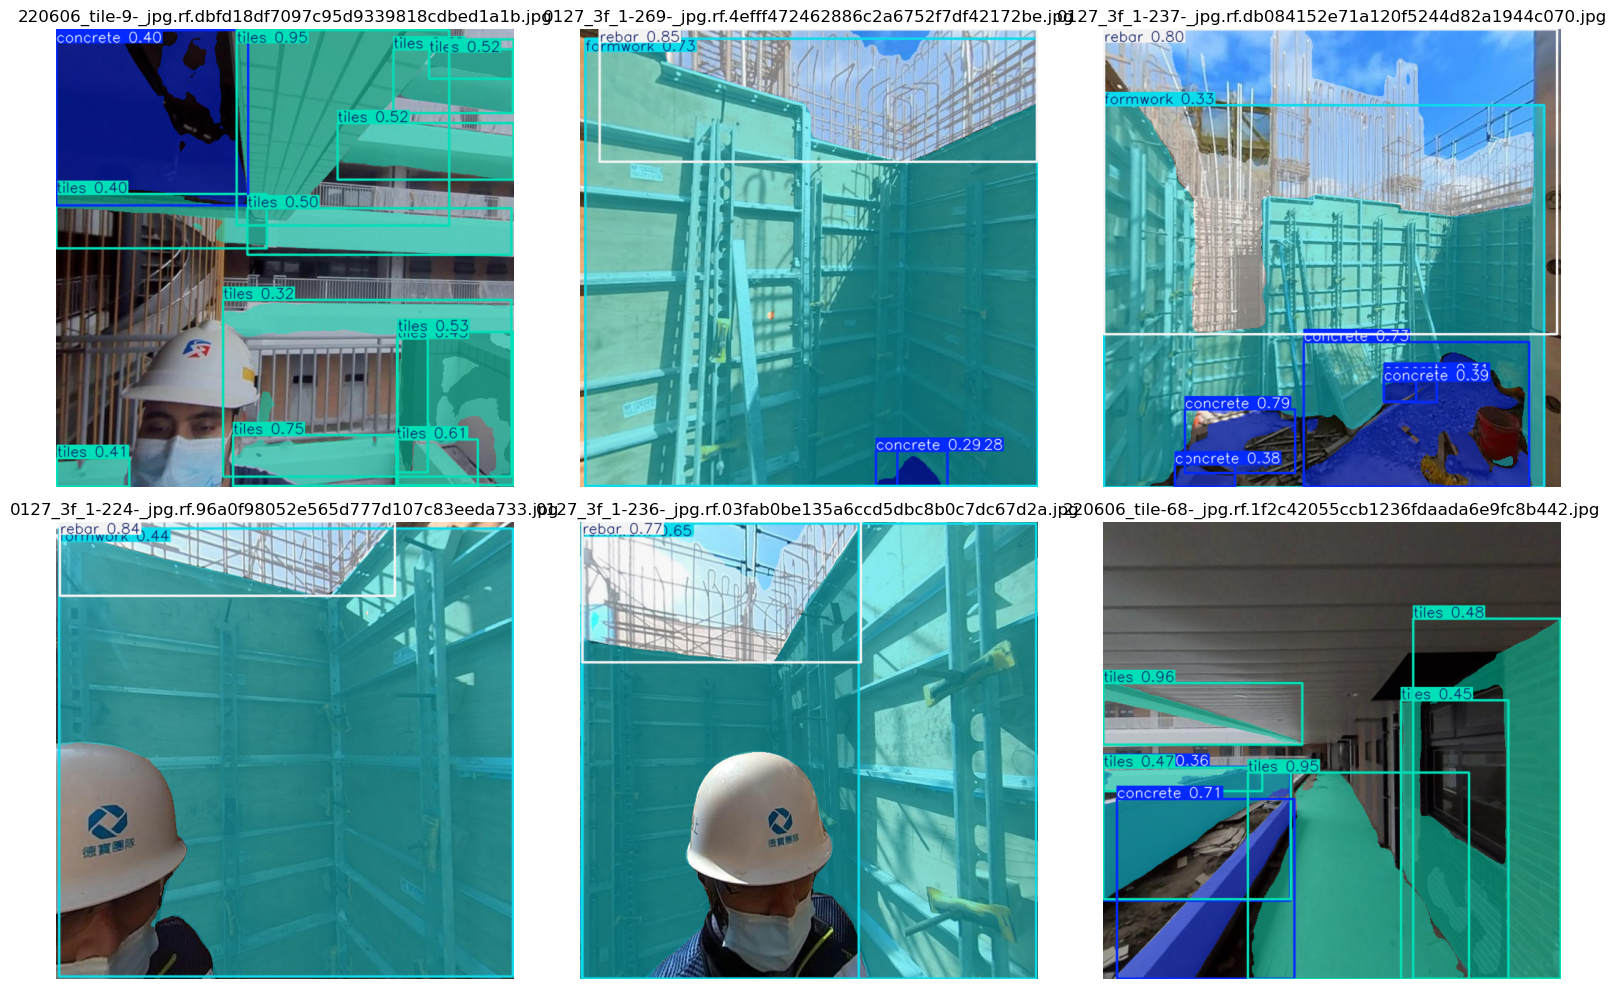

Saved predictions: /Users/nehanaiksatam/Downloads/outputs/sample_predictions


In [14]:
def predict_segmentation(model, image_path, conf=CONF_THRESHOLD):
    results = model.predict(
        source=str(image_path),
        imgsz=IMG_SIZE,
        conf=conf,
        retina_masks=True,
        verbose=False
    )
    return results[0]


test_images = image_paths_in(test_img_dir if test_img_dir is not None else val_img_dir)

if len(test_images) == 0:
    test_images = image_paths_in(val_img_dir)

sample_test = random.sample(test_images, min(6, len(test_images)))

pred_output_dir = OUTPUT_DIR / "sample_predictions"
pred_output_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(16, 10))

for i, img_path in enumerate(sample_test):
    result = predict_segmentation(best_model, img_path)
    plotted = result.plot()
    plotted = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)

    save_path = pred_output_dir / f"prediction_{i}_{Path(img_path).name}"
    cv2.imwrite(str(save_path), cv2.cvtColor(plotted, cv2.COLOR_RGB2BGR))

    plt.subplot(2, 3, i + 1)
    plt.imshow(plotted)
    plt.title(Path(img_path).name)
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Saved predictions:", pred_output_dir)

# 12. Progress calculation from segmentation masks

In [15]:
def get_result_shape(result):
    h, w = result.orig_shape
    return int(h), int(w)


def resize_mask(mask, h, w):
    mask = mask.astype(np.float32)
    mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)
    return mask > 0.5


def create_default_zones(h, w):
    return {
        "zone_left": (0, 0, w // 3, h),
        "zone_center": (w // 3, 0, 2 * w // 3, h),
        "zone_right": (2 * w // 3, 0, w, h),
    }


def get_class_masks(result, class_names):
    h, w = get_result_shape(result)
    class_masks = {name: np.zeros((h, w), dtype=bool) for name in class_names}

    if result.masks is None or result.boxes is None:
        return class_masks

    masks = result.masks.data.cpu().numpy()
    cls_ids = result.boxes.cls.cpu().numpy().astype(int)
    confs = result.boxes.conf.cpu().numpy()

    for mask, cls_id, conf in zip(masks, cls_ids, confs):
        if conf < CONF_THRESHOLD:
            continue
        if cls_id >= len(class_names):
            continue

        cls_name = class_names[cls_id]
        m = resize_mask(mask, h, w)
        class_masks[cls_name] |= m

    return class_masks


def calculate_zone_progress(result, class_names, zones=None):
    h, w = get_result_shape(result)

    if zones is None:
        zones = {"full_image": (0, 0, w, h)}

    class_masks = get_class_masks(result, class_names)
    rows = []

    for zone_name, (x1, y1, x2, y2) in zones.items():
        zone_area = max((x2 - x1) * (y2 - y1), 1)
        row = {"zone": zone_name}
        progress = 0.0

        for cls_name in class_names:
            zone_mask = class_masks[cls_name][y1:y2, x1:x2]
            coverage_pct = 100.0 * zone_mask.sum() / zone_area
            row[f"{cls_name}_coverage_pct"] = round(float(coverage_pct), 2)
            progress += PROGRESS_WEIGHTS.get(cls_name, 0.0) * coverage_pct

        row["visual_progress_pct"] = round(float(min(progress, 100.0)), 2)
        rows.append(row)

    return pd.DataFrame(rows)


one_image = sample_test[0]
one_result = predict_segmentation(best_model, one_image)

h, w = get_result_shape(one_result)
zones = create_default_zones(h, w)

progress_df = calculate_zone_progress(one_result, CLASS_NAMES, zones)
display(progress_df)

progress_df.to_csv(OUTPUT_DIR / "single_image_progress.csv", index=False)

,zone,concrete_coverage_pct,formwork_coverage_pct,rebar_coverage_pct,tiles_coverage_pct,visual_progress_pct
0,zone_left,29.56,0.0,0.0,6.47,11.31
1,zone_center,4.38,0.0,0.0,48.00,8.73
2,zone_right,0.00,0.0,0.0,62.73,9.41


# 13. Visualize zones + masks

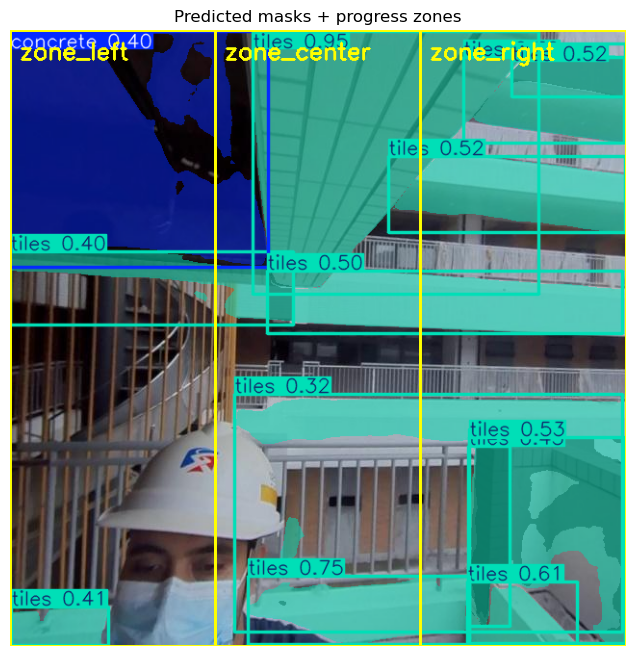

In [16]:
def plot_result_with_zones(result, zones):
    plotted = result.plot()
    plotted = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)

    for zone_name, (x1, y1, x2, y2) in zones.items():
        cv2.rectangle(plotted, (x1, y1), (x2, y2), (255, 255, 0), 2)
        cv2.putText(
            plotted,
            zone_name,
            (x1 + 10, y1 + 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255, 255, 0),
            2
        )

    plt.figure(figsize=(12, 8))
    plt.imshow(plotted)
    plt.title("Predicted masks + progress zones")
    plt.axis("off")
    plt.show()


plot_result_with_zones(one_result, zones)

# 14. Depth estimation

This uses relative monocular depth. It is not a real point cloud.

In [17]:
from transformers import pipeline

DEPTH_MODEL_NAME = "depth-anything/Depth-Anything-V2-Small-hf"
DEPTH_DEVICE = 0 if torch.cuda.is_available() else -1

depth_pipe = pipeline(
    task="depth-estimation",
    model=DEPTH_MODEL_NAME,
    device=DEPTH_DEVICE
)

print("Loaded depth model:", DEPTH_MODEL_NAME)

config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/99.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

Loaded depth model: depth-anything/Depth-Anything-V2-Small-hf


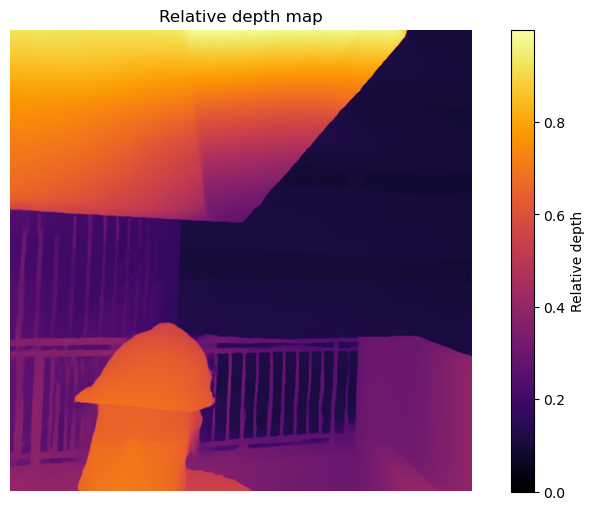

In [18]:
def estimate_depth(image_path):
    image = Image.open(image_path).convert("RGB")
    output = depth_pipe(image)

    if "predicted_depth" in output:
        depth = output["predicted_depth"].squeeze().detach().cpu().numpy().astype(np.float32)
    else:
        depth = np.array(output["depth"]).astype(np.float32)

    depth_min = float(depth.min())
    depth_max = float(depth.max())
    depth_norm = (depth - depth_min) / (depth_max - depth_min + 1e-6)

    return depth_norm


depth_map = estimate_depth(one_image)

plt.figure(figsize=(10, 6))
plt.imshow(depth_map, cmap="inferno")
plt.colorbar(label="Relative depth")
plt.title("Relative depth map")
plt.axis("off")
plt.show()

# 15. Mask-depth fusion

In [19]:
def calculate_mask_depth_stats(result, depth_map, class_names):
    h, w = get_result_shape(result)
    depth_resized = cv2.resize(depth_map, (w, h), interpolation=cv2.INTER_LINEAR)

    rows = []

    if result.masks is None or result.boxes is None:
        return pd.DataFrame(rows)

    masks = result.masks.data.cpu().numpy()
    cls_ids = result.boxes.cls.cpu().numpy().astype(int)
    confs = result.boxes.conf.cpu().numpy()

    for i, (mask, cls_id, conf) in enumerate(zip(masks, cls_ids, confs)):
        if conf < CONF_THRESHOLD or cls_id >= len(class_names):
            continue

        cls_name = class_names[cls_id]
        m = resize_mask(mask, h, w)
        pixels = depth_resized[m]

        if len(pixels) == 0:
            continue

        rows.append({
            "instance_id": i,
            "class_name": cls_name,
            "confidence": round(float(conf), 3),
            "mask_area_pixels": int(m.sum()),
            "mean_relative_depth": round(float(np.mean(pixels)), 4),
            "median_relative_depth": round(float(np.median(pixels)), 4),
            "min_relative_depth": round(float(np.min(pixels)), 4),
            "max_relative_depth": round(float(np.max(pixels)), 4),
        })

    return pd.DataFrame(rows)


depth_stats_df = calculate_mask_depth_stats(one_result, depth_map, CLASS_NAMES)
display(depth_stats_df)

depth_stats_df.to_csv(OUTPUT_DIR / "single_image_depth_stats.csv", index=False)

,instance_id,class_name,confidence,mask_area_pixels,mean_relative_depth,median_relative_depth,min_relative_depth,max_relative_depth
0,0,tiles,0.950,48263,0.6698,0.6888,0.0158,1.0000
1,1,tiles,0.745,11297,0.3144,0.3173,0.1842,0.3681
2,2,tiles,0.611,4399,0.3549,0.3534,0.2974,0.4113
3,3,tiles,0.525,24210,0.3201,0.3101,0.0764,0.3976
4,4,tiles,0.525,4492,0.1069,0.1062,0.0232,0.1262
5,5,tiles,0.518,13364,0.1039,0.1024,0.0630,0.4753
6,6,tiles,0.504,18592,0.1094,0.1089,0.0882,0.3862
7,7,tiles,0.449,6420,0.2989,0.3057,0.0938,0.3212
8,8,tiles,0.409,3638,0.3860,0.3892,0.2591,0.6383
9,9,concrete,0.403,46266,0.7215,0.7187,0.4382,0.9370


# 16. Depth-band progress

This turns depth into useful analysis: near, middle, and far progress.

In [20]:
def calculate_depth_band_progress(result, depth_map, class_names):
    h, w = get_result_shape(result)
    depth_resized = cv2.resize(depth_map, (w, h), interpolation=cv2.INTER_LINEAR)
    class_masks = get_class_masks(result, class_names)

    q1, q2 = np.quantile(depth_resized, [0.33, 0.66])

    bands = {
        "near_band": depth_resized <= q1,
        "middle_band": (depth_resized > q1) & (depth_resized <= q2),
        "far_band": depth_resized > q2,
    }

    rows = []

    for band_name, band_mask in bands.items():
        band_area = max(int(band_mask.sum()), 1)
        row = {"depth_band": band_name}
        progress = 0.0

        for cls_name in class_names:
            overlap = class_masks[cls_name] & band_mask
            coverage_pct = 100.0 * overlap.sum() / band_area
            row[f"{cls_name}_coverage_pct"] = round(float(coverage_pct), 2)
            progress += PROGRESS_WEIGHTS.get(cls_name, 0.0) * coverage_pct

        row["depth_band_progress_pct"] = round(float(min(progress, 100.0)), 2)
        rows.append(row)

    return pd.DataFrame(rows)


depth_band_df = calculate_depth_band_progress(one_result, depth_map, CLASS_NAMES)
display(depth_band_df)

depth_band_df.to_csv(OUTPUT_DIR / "single_image_depth_band_progress.csv", index=False)

,depth_band,concrete_coverage_pct,formwork_coverage_pct,rebar_coverage_pct,tiles_coverage_pct,depth_band_progress_pct
0,near_band,0.00,0.0,0.0,45.80,6.87
1,middle_band,0.04,0.0,0.0,39.47,5.93
2,far_band,33.19,0.0,0.0,32.24,16.45


# 17. Planned vs actual progress

In [21]:
planned_schedule = pd.DataFrame({
    "frame_index": [0, 10, 20, 30, 40, 50],
    "planned_progress_pct": [10, 20, 35, 50, 65, 80]
})

display(planned_schedule)
planned_schedule.to_csv(OUTPUT_DIR / "planned_schedule.csv", index=False)


def compare_actual_to_planned(actual_progress_pct, frame_index, planned_schedule_df):
    idx = (planned_schedule_df["frame_index"] - frame_index).abs().idxmin()
    planned = float(planned_schedule_df.loc[idx, "planned_progress_pct"])
    gap = actual_progress_pct - planned

    if gap >= 5:
        status = "Ahead"
    elif gap <= -5:
        status = "Behind"
    else:
        status = "On Track"

    return {
        "frame_index": int(frame_index),
        "actual_progress_pct": round(float(actual_progress_pct), 2),
        "planned_progress_pct": round(float(planned), 2),
        "gap_pct": round(float(gap), 2),
        "status": status,
    }


actual_progress = float(progress_df["visual_progress_pct"].mean())
comparison = compare_actual_to_planned(actual_progress, 0, planned_schedule)
comparison

,frame_index,planned_progress_pct
0,0,10
1,10,20
2,20,35
3,30,50
4,40,65
5,50,80


{'frame_index': 0,
 'actual_progress_pct': 9.82,
 'planned_progress_pct': 10.0,
 'gap_pct': -0.18,
 'status': 'On Track'}

# 18. Image sequence progress + temporal smoothing

100%|███████████████████████████████████████████| 30/30 [00:02<00:00, 14.88it/s]


,frame_index,image_path,actual_visual_progress_pct,concrete_coverage_pct,formwork_coverage_pct,rebar_coverage_pct,tiles_coverage_pct,actual_progress_pct,planned_progress_pct,gap_pct,status,smoothed_progress_pct
0,0,/Users/nehanaiksatam/Downloads/data/constructi...,9.15,1.99,21.33,12.50,0.0,9.15,10.0,-0.85,On Track,9.15
1,1,/Users/nehanaiksatam/Downloads/data/constructi...,8.94,0.00,30.75,5.03,0.0,8.94,10.0,-1.06,On Track,9.08
2,2,/Users/nehanaiksatam/Downloads/data/constructi...,23.99,0.00,0.00,95.97,0.0,23.99,10.0,13.99,Ahead,14.30
3,3,/Users/nehanaiksatam/Downloads/data/constructi...,15.19,11.71,11.27,33.11,0.0,15.19,10.0,5.19,Ahead,14.61
4,4,/Users/nehanaiksatam/Downloads/data/constructi...,13.43,0.76,52.66,0.00,0.0,13.43,10.0,3.43,On Track,14.20


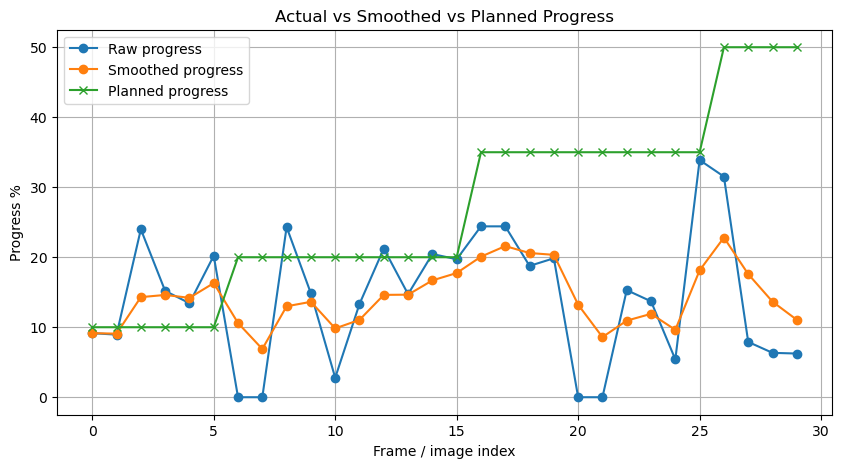

In [22]:
def exponential_smoothing(values, alpha=0.35):
    values = list(values)

    if not values:
        return []

    smoothed = [values[0]]

    for v in values[1:]:
        smoothed.append(alpha * v + (1 - alpha) * smoothed[-1])

    return smoothed


def process_image_sequence(image_paths, model, class_names, planned_schedule_df=None, max_images=50):
    rows = []
    image_paths = list(image_paths)[:max_images]

    for frame_idx, img_path in enumerate(tqdm(image_paths)):
        result = predict_segmentation(model, img_path)

        h, w = get_result_shape(result)
        zones = create_default_zones(h, w)
        progress = calculate_zone_progress(result, class_names, zones)

        actual_progress = float(progress["visual_progress_pct"].mean())

        row = {
            "frame_index": frame_idx,
            "image_path": str(img_path),
            "actual_visual_progress_pct": round(actual_progress, 2),
        }

        for cls_name in class_names:
            col = f"{cls_name}_coverage_pct"
            if col in progress.columns:
                row[col] = round(float(progress[col].mean()), 2)

        if planned_schedule_df is not None:
            row.update(compare_actual_to_planned(actual_progress, frame_idx, planned_schedule_df))

        rows.append(row)

    df = pd.DataFrame(rows)

    if len(df) > 0:
        df["smoothed_progress_pct"] = exponential_smoothing(
            df["actual_visual_progress_pct"].tolist(),
            alpha=0.35
        )
        df["smoothed_progress_pct"] = df["smoothed_progress_pct"].round(2)

    return df


sequence_images = sorted(test_images)[:30]

sequence_report = process_image_sequence(
    sequence_images,
    best_model,
    CLASS_NAMES,
    planned_schedule_df=planned_schedule,
    max_images=30
)

display(sequence_report.head())
sequence_report.to_csv(OUTPUT_DIR / "image_sequence_progress_report.csv", index=False)

plt.figure(figsize=(10, 5))
plt.plot(sequence_report["frame_index"], sequence_report["actual_visual_progress_pct"], marker="o", label="Raw progress")
plt.plot(sequence_report["frame_index"], sequence_report["smoothed_progress_pct"], marker="o", label="Smoothed progress")

if "planned_progress_pct" in sequence_report.columns:
    plt.plot(sequence_report["frame_index"], sequence_report["planned_progress_pct"], marker="x", label="Planned progress")

plt.title("Actual vs Smoothed vs Planned Progress")
plt.xlabel("Frame / image index")
plt.ylabel("Progress %")
plt.grid(True)
plt.legend()
plt.show()

# 19. Optional video processing

Put a video at:

`data/sample_construction_video.mp4`

In [23]:
VIDEO_PATH = DATA_DIR / "sample_construction_video.mp4"

def process_video(video_path, model, class_names, frame_stride=30, max_frames=80):
    video_path = Path(video_path)

    if not video_path.exists():
        print("Video not found:", video_path)
        print("Skipping video processing.")
        return pd.DataFrame()

    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    annotated_dir = OUTPUT_DIR / "annotated_video_frames"
    annotated_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    frame_id = 0
    processed = 0
    start_time = time.time()

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        if frame_id % frame_stride == 0:
            temp_path = OUTPUT_DIR / "_temp_frame.jpg"
            cv2.imwrite(str(temp_path), frame)

            result = predict_segmentation(model, temp_path)

            h, w = get_result_shape(result)
            zones = create_default_zones(h, w)
            progress = calculate_zone_progress(result, class_names, zones)
            actual_progress = float(progress["visual_progress_pct"].mean())

            row = {
                "frame_id": frame_id,
                "processed_index": processed,
                "actual_visual_progress_pct": round(actual_progress, 2),
            }

            for cls_name in class_names:
                col = f"{cls_name}_coverage_pct"

                if col in progress.columns:
                    row[col] = round(float(progress[col].mean()), 2)

            rows.append(row)

            if processed < 20:
                annotated = result.plot()
                out_path = annotated_dir / f"frame_{frame_id:06d}.jpg"
                cv2.imwrite(str(out_path), annotated)

            processed += 1

            if processed >= max_frames:
                break

        frame_id += 1

    cap.release()
    elapsed = time.time() - start_time

    df = pd.DataFrame(rows)

    if len(df) > 0:
        df["smoothed_progress_pct"] = exponential_smoothing(df["actual_visual_progress_pct"], alpha=0.35)
        df["processing_fps_sampled_frames"] = round(len(df) / max(elapsed, 1e-6), 2)

    return df


video_report = process_video(VIDEO_PATH, best_model, CLASS_NAMES)

if len(video_report) > 0:
    display(video_report.head())
    video_report.to_csv(OUTPUT_DIR / "video_progress_report.csv", index=False)

Video not found: /Users/nehanaiksatam/Downloads/data/sample_construction_video.mp4
Skipping video processing.


# 20. Error analysis

Simple failure analysis:
- ground truth class present but prediction missing
- prediction class present but ground truth missing

In [24]:
def gt_class_set(img_path):
    label_path = label_path_for_image(img_path)
    cls_ids = parse_yolo_label_file(label_path)

    return {
        CLASS_NAMES[i]
        for i in cls_ids
        if 0 <= i < len(CLASS_NAMES)
    }


def pred_class_set(result):
    if result.boxes is None:
        return set()

    cls_ids = result.boxes.cls.cpu().numpy().astype(int)
    confs = result.boxes.conf.cpu().numpy()

    return {
        CLASS_NAMES[i]
        for i, conf in zip(cls_ids, confs)
        if 0 <= i < len(CLASS_NAMES) and conf >= CONF_THRESHOLD
    }


def run_simple_error_analysis(image_paths, model, max_images=100):
    rows = []
    error_dir = OUTPUT_DIR / "error_analysis_examples"
    error_dir.mkdir(parents=True, exist_ok=True)

    for img_path in tqdm(list(image_paths)[:max_images]):
        result = predict_segmentation(model, img_path)

        gt = gt_class_set(img_path)
        pred = pred_class_set(result)

        missed = sorted(gt - pred)
        extra = sorted(pred - gt)

        if missed or extra:
            rows.append({
                "image_path": str(img_path),
                "gt_classes": ",".join(sorted(gt)),
                "pred_classes": ",".join(sorted(pred)),
                "missed_classes": ",".join(missed),
                "extra_pred_classes": ",".join(extra),
            })

            if len(rows) <= 20:
                plotted = result.plot()
                save_path = error_dir / f"error_{len(rows):03d}_{Path(img_path).name}"
                cv2.imwrite(str(save_path), plotted)

    return pd.DataFrame(rows)


error_df = run_simple_error_analysis(test_images, best_model, max_images=100)
display(error_df.head(20))

error_df.to_csv(OUTPUT_DIR / "error_analysis.csv", index=False)
print("Saved error examples to:", OUTPUT_DIR / "error_analysis_examples")

100%|███████████████████████████████████████████| 63/63 [00:04<00:00, 13.58it/s]


,image_path,gt_classes,pred_classes,missed_classes,extra_pred_classes
0,/Users/nehanaiksatam/Downloads/data/constructi...,formwork,,formwork,
1,/Users/nehanaiksatam/Downloads/data/constructi...,formwork,,formwork,
2,/Users/nehanaiksatam/Downloads/data/constructi...,"formwork,rebar","concrete,formwork,rebar",,concrete
3,/Users/nehanaiksatam/Downloads/data/constructi...,"formwork,rebar","concrete,formwork,rebar",,concrete
4,/Users/nehanaiksatam/Downloads/data/constructi...,formwork,,formwork,
5,/Users/nehanaiksatam/Downloads/data/constructi...,formwork,,formwork,
6,/Users/nehanaiksatam/Downloads/data/constructi...,"concrete,formwork","concrete,formwork,rebar",,rebar
7,/Users/nehanaiksatam/Downloads/data/constructi...,"formwork,rebar",formwork,rebar,
8,/Users/nehanaiksatam/Downloads/data/constructi...,concrete,"concrete,formwork,rebar",,"formwork,rebar"
9,/Users/nehanaiksatam/Downloads/data/constructi...,tiles,"concrete,tiles",,concrete


Saved error examples to: /Users/nehanaiksatam/Downloads/outputs/error_analysis_examples


# 21. Speed benchmark

In [25]:
def benchmark_yolo(model, image_paths, n_images=30):
    image_paths = list(image_paths)[:n_images]

    if len(image_paths) == 0:
        return {"num_images": 0}

    _ = predict_segmentation(model, image_paths[0])

    times = []

    for img_path in tqdm(image_paths):
        start = time.time()
        _ = predict_segmentation(model, img_path)
        times.append(time.time() - start)

    avg_time = float(np.mean(times))
    fps = 1.0 / avg_time if avg_time > 0 else 0.0

    return {
        "num_images": len(image_paths),
        "avg_yolo_inference_time_sec": round(avg_time, 4),
        "estimated_yolo_fps": round(fps, 2),
        "min_time_sec": round(float(np.min(times)), 4),
        "max_time_sec": round(float(np.max(times)), 4),
    }


speed_summary = benchmark_yolo(best_model, test_images, n_images=30)
print(json.dumps(speed_summary, indent=2))
pd.DataFrame([speed_summary]).to_csv(OUTPUT_DIR / "speed_benchmark.csv", index=False)

100%|███████████████████████████████████████████| 30/30 [00:02<00:00, 14.52it/s]

{
  "num_images": 30,
  "avg_yolo_inference_time_sec": 0.0687,
  "estimated_yolo_fps": 14.56,
  "min_time_sec": 0.0449,
  "max_time_sec": 0.0799
}


# 22. Depth speed benchmark

In [26]:
def benchmark_depth(image_paths, n_images=10):
    image_paths = list(image_paths)[:n_images]

    if len(image_paths) == 0:
        return {"num_images": 0}

    _ = estimate_depth(image_paths[0])

    times = []

    for img_path in tqdm(image_paths):
        start = time.time()
        _ = estimate_depth(img_path)
        times.append(time.time() - start)

    avg_time = float(np.mean(times))
    fps = 1.0 / avg_time if avg_time > 0 else 0.0

    return {
        "num_images": len(image_paths),
        "avg_depth_time_sec": round(avg_time, 4),
        "estimated_depth_fps": round(fps, 2),
        "min_depth_time_sec": round(float(np.min(times)), 4),
        "max_depth_time_sec": round(float(np.max(times)), 4),
    }


depth_speed_summary = benchmark_depth(test_images, n_images=10)
print(json.dumps(depth_speed_summary, indent=2))
pd.DataFrame([depth_speed_summary]).to_csv(OUTPUT_DIR / "depth_speed_benchmark.csv", index=False)

100%|███████████████████████████████████████████| 10/10 [00:02<00:00,  3.42it/s]

{
  "num_images": 10,
  "avg_depth_time_sec": 0.2917,
  "estimated_depth_fps": 3.43,
  "min_depth_time_sec": 0.284,
  "max_depth_time_sec": 0.3072
}


# 23. Optional ablation study

Run only after the main model works.

Compares:
- YOLOv8n-seg
- YOLOv8s-seg

In [27]:
RUN_ABLATION = False

def run_ablation(model_names, data_yaml, epochs=20):
    rows = []

    for model_name in model_names:
        print("\nTraining ablation model:", model_name)

        ab_model = YOLO(model_name)
        run_name = f"ablation_{model_name.replace('.pt', '')}"

        ab_model.train(
            data=str(data_yaml),
            task="segment",
            epochs=epochs,
            imgsz=IMG_SIZE,
            batch=BATCH,
            patience=5,
            workers=2,
            seed=SEED,
            project=str(MODEL_DIR),
            name=run_name,
            exist_ok=True,
            verbose=False
        )

        best_path = MODEL_DIR / run_name / "weights" / "best.pt"
        m = YOLO(str(best_path))
        val = m.val(data=str(data_yaml), imgsz=IMG_SIZE, conf=CONF_THRESHOLD, verbose=False)

        rows.append({
            "model": model_name,
            "mask_precision": round(float(safe_get(val, "seg.mp", 0)), 4),
            "mask_recall": round(float(safe_get(val, "seg.mr", 0)), 4),
            "mask_map50": round(float(safe_get(val, "seg.map50", 0)), 4),
            "mask_map50_95": round(float(safe_get(val, "seg.map", 0)), 4),
        })

    return pd.DataFrame(rows)


if RUN_ABLATION:
    ablation_df = run_ablation(["yolov8n-seg.pt", "yolov8s-seg.pt"], DATA_YAML, epochs=20)
    display(ablation_df)
    ablation_df.to_csv(OUTPUT_DIR / "ablation_results.csv", index=False)
else:
    print("Ablation skipped. Set RUN_ABLATION = True to run it.")

Ablation skipped. Set RUN_ABLATION = True to run it.


# 24. Final senior-level project report

In [28]:
final_report = {
    "project_name": "BuildTrack 3D: Depth-Aware Construction Progress Monitoring",
    "task": "Instance segmentation + monocular depth estimation + visual progress scoring",
    "classes": CLASS_NAMES,
    "model": str(BEST_MODEL_PATH),
    "image_size": IMG_SIZE,
    "epochs": EPOCHS,
    "confidence_threshold": CONF_THRESHOLD,
    "progress_weights": PROGRESS_WEIGHTS,
    "outputs": {
        "dataset_health": str(OUTPUT_DIR / "dataset_health_summary.csv"),
        "class_distribution": str(OUTPUT_DIR / "class_distribution.csv"),
        "overall_metrics": str(OUTPUT_DIR / "overall_validation_metrics.csv"),
        "per_class_metrics": str(OUTPUT_DIR / "per_class_metrics.csv"),
        "single_image_progress": str(OUTPUT_DIR / "single_image_progress.csv"),
        "single_image_depth_stats": str(OUTPUT_DIR / "single_image_depth_stats.csv"),
        "depth_band_progress": str(OUTPUT_DIR / "single_image_depth_band_progress.csv"),
        "image_sequence_progress": str(OUTPUT_DIR / "image_sequence_progress_report.csv"),
        "error_analysis": str(OUTPUT_DIR / "error_analysis.csv"),
        "speed_benchmark": str(OUTPUT_DIR / "speed_benchmark.csv"),
        "depth_speed_benchmark": str(OUTPUT_DIR / "depth_speed_benchmark.csv"),
    },
    "limitations": [
        "Progress is visual progress, not certified construction completion.",
        "Monocular depth is relative unless calibrated with known scale, stereo, LiDAR, or RGB-D sensors.",
        "Dataset size is limited, so project-specific data would be needed before production use.",
        "No point cloud or BIM alignment is used in this version."
    ],
    "interview_summary": (
        "I trained a YOLO segmentation model to detect concrete, formwork, rebar, and tiles. "
        "I converted segmentation mask coverage into zone-level visual progress, added temporal smoothing, "
        "used Depth Anything V2 for relative depth maps, fused masks with depth for 2.5D progress analysis, "
        "and reported accuracy, per-class metrics, error cases, and inference speed."
    )
}

with open(OUTPUT_DIR / "final_senior_project_report.json", "w") as f:
    json.dump(final_report, f, indent=2)

print(json.dumps(final_report, indent=2))
print("\nSaved:", OUTPUT_DIR / "final_senior_project_report.json")

{
  "project_name": "BuildTrack 3D: Depth-Aware Construction Progress Monitoring",
  "task": "Instance segmentation + monocular depth estimation + visual progress scoring",
  "classes": [
    "concrete",
    "formwork",
    "rebar",
    "tiles"
  ],
  "model": "/Users/nehanaiksatam/Downloads/models/buildtrack3d_yolo_seg/weights/best.pt",
  "image_size": 640,
  "epochs": 40,
  "confidence_threshold": 0.25,
  "progress_weights": {
    "rebar": 0.25,
    "formwork": 0.25,
    "concrete": 0.35,
    "tiles": 0.15
  },
  "outputs": {
    "dataset_health": "/Users/nehanaiksatam/Downloads/outputs/dataset_health_summary.csv",
    "class_distribution": "/Users/nehanaiksatam/Downloads/outputs/class_distribution.csv",
    "overall_metrics": "/Users/nehanaiksatam/Downloads/outputs/overall_validation_metrics.csv",
    "per_class_metrics": "/Users/nehanaiksatam/Downloads/outputs/per_class_metrics.csv",
    "single_image_progress": "/Users/nehanaiksatam/Downloads/outputs/single_image_progress.csv",
  

# 25. Interview explanation

Use this:

> I built a depth-aware construction progress monitoring system using public construction-site imagery. I trained YOLO segmentation to detect concrete, formwork, rebar, and tiles. I used segmentation masks because progress monitoring needs area coverage, not only object boxes. I then added a monocular depth-estimation model to create relative depth maps and fused depth with masks to analyze near, middle, and far construction activity. I compared detected visual progress with a simulated as-planned schedule and generated metrics, error analysis, and performance benchmarks.

## Safe limitation statement

> This system estimates visual progress. For exact metric progress, I would add camera calibration, known scale markers, stereo/LiDAR/RGB-D data, point clouds, or BIM alignment.

## What to mention for senior roles

- why segmentation was chosen
- how dataset quality was checked
- how metrics were evaluated
- how failure cases were analyzed
- why monocular depth is useful but limited
- how the system could scale later with site cameras, storage, batch processing, model monitoring, and retraining